# Regresión Logística Simple — Anemia Infantil
## ENDES 2024 (RECH6) · Universidad Nacional del Altiplano

| | |
|---|---|
| **Variable dependiente (Y)** | `grupo_anemia` — presencia / ausencia de anemia (OMS 2024 / RM 251-2024-MINSA, variable `HC57A`) |
| **Variable independiente (X)** | `talla_edad_z` — Z-score Talla/Edad (OMS), variable `HC70`; valores más negativos → desnutrición crónica |


## 0 · Instalación de dependencias

In [1]:
# Ejecutar solo si falta alguna librería
!pip install -q scikit-learn statsmodels matplotlib seaborn pandas numpy

## 1 · Importación de librerías

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_predict, StratifiedKFold
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve
)
from sklearn.preprocessing import LabelEncoder

import statsmodels.api as sm
from scipy import stats

import warnings
warnings.filterwarnings('ignore')

np.random.seed(123)
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (7, 5)})
print('Librerías importadas correctamente.')

Librerías importadas correctamente.


## 2 · Preparación del dataset

Se lee `RECH6_2024.csv`, se filtran valores válidos y se construye la variable binaria de anemia.

> **Subir el archivo:** en Google Colab usa el panel de archivos (ícono de carpeta) o la celda de carga de abajo.

In [3]:
# ── Solo en Google Colab ──────────────────────────────────────────────────────
from google.colab import files
uploaded = files.upload()   # seleccionar RECH6_2024.csv
# ─────────────────────────────────────────────────────────────────────────────

Saving RECH6_2024.csv to RECH6_2024.csv


In [4]:
df_crudo = pd.read_csv('RECH6_2024.csv', sep=';')
print(f'Dataset original: {df_crudo.shape[0]} filas × {df_crudo.shape[1]} columnas')

datos_raw = df_crudo[['HC70', 'HC57A']].copy()
datos_raw.columns = ['talla_edad_z_x100', 'anemia_oms']

mask_validos = (
    datos_raw['anemia_oms'].isin([1, 2, 3, 4]) &
    (datos_raw['talla_edad_z_x100'].abs() < 9000)
)

print(f'Filas excluidas (código "no medido"): {(~mask_validos).sum()}')
print(f'Filas válidas: {mask_validos.sum()} de {len(datos_raw)}')

datos_raw = datos_raw[mask_validos].copy()
datos_raw['talla_edad_z'] = datos_raw['talla_edad_z_x100'] / 100
# 0 = Sin anemia (anemia_oms==4), 1 = Con anemia
datos_raw['anemia'] = (datos_raw['anemia_oms'] != 4).astype(int)

datos = datos_raw[['anemia', 'talla_edad_z']].reset_index(drop=True)
print('\nPrimeras observaciones:')
datos.head()

Dataset original: 20290 filas × 43 columnas
Filas excluidas (código "no medido"): 1984
Filas válidas: 18306 de 20290

Primeras observaciones:


,anemia,talla_edad_z
0,0,-0.88
1,0,-1.67
2,0,-0.78
3,1,-0.27
4,0,-1.19


## 3 · Análisis Exploratorio de Datos

In [5]:
print('=== Estadísticos descriptivos ===')
print(datos.describe())

print('\n=== Distribución de clases ===')
vc = datos['anemia'].value_counts().rename({0: 'Sin anemia', 1: 'Con anemia'})
print(vc.to_frame('n').assign(pct=lambda x: (x['n']/len(datos)*100).round(2)))

print('\n=== Resumen por grupo ===')
label_map = {0: 'Sin anemia', 1: 'Con anemia'}
print(
    datos.assign(grupo=datos['anemia'].map(label_map))
         .groupby('grupo')['talla_edad_z']
         .agg(['mean','median','min','max'])
         .round(4)
)

=== Estadísticos descriptivos ===
             anemia  talla_edad_z
count  18306.000000  18306.000000
mean       0.314323     -0.877772
std        0.464258      1.012571
min        0.000000     -5.510000
25%        0.000000     -1.550000
50%        0.000000     -0.880000
75%        1.000000     -0.200000
max        1.000000      3.540000

=== Distribución de clases ===
                n    pct
anemia                  
Sin anemia  12552  68.57
Con anemia   5754  31.43

=== Resumen por grupo ===
              mean  median   min   max
grupo                                 
Con anemia -1.0160   -1.02 -5.24  3.29
Sin anemia -0.8144   -0.82 -5.51  3.54


## 4 · Visualización de datos

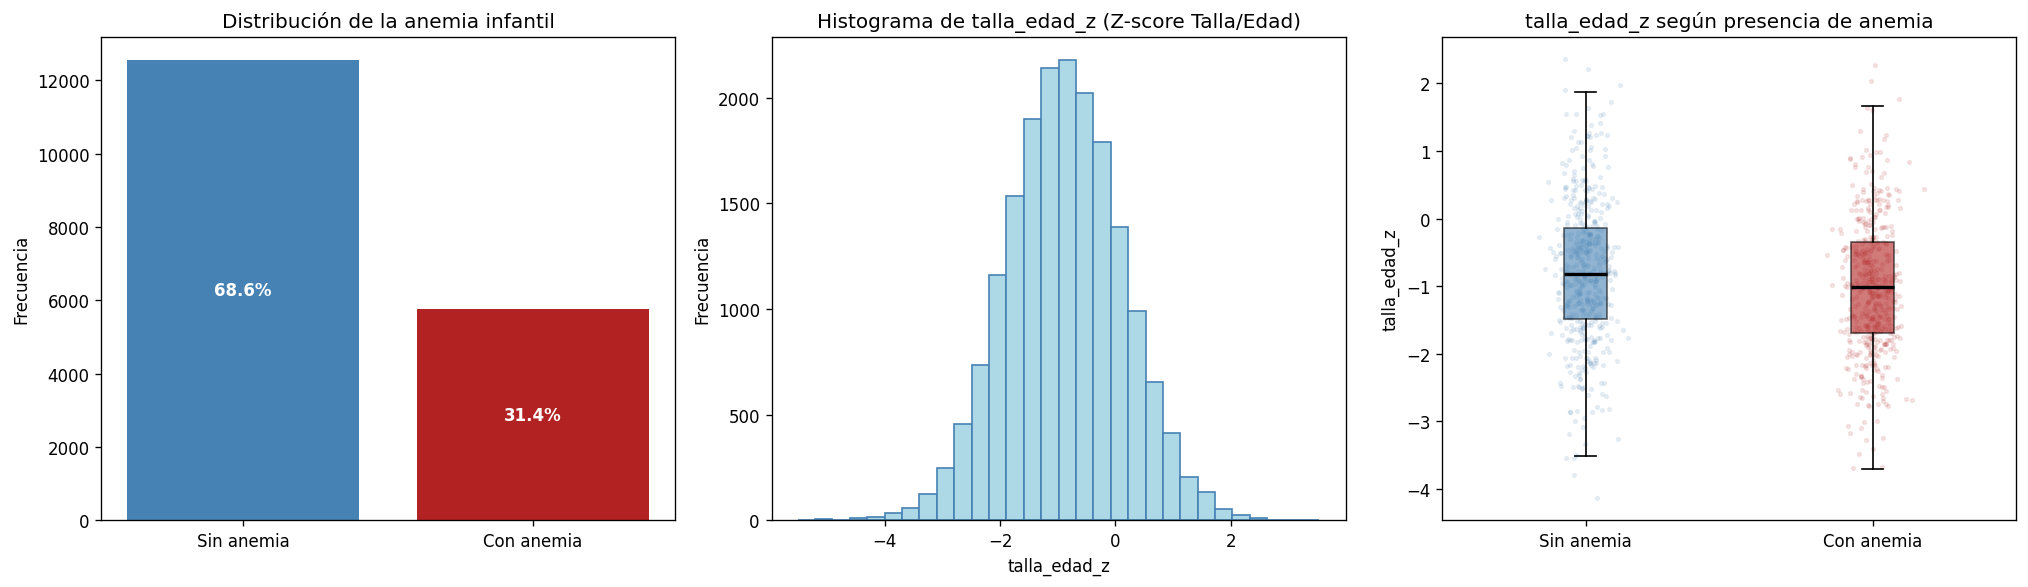

> A mejor talla/edad (menos desnutrición crónica), menor concentración de anemia.


In [6]:
colores = {0: 'steelblue', 1: 'firebrick'}
etiquetas = {0: 'Sin anemia', 1: 'Con anemia'}

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# ── Gráfico 1: distribución de clases ─────────────────────────────────────────
counts = datos['anemia'].value_counts().sort_index()
bars = axes[0].bar(
    [etiquetas[i] for i in counts.index],
    counts.values,
    color=[colores[i] for i in counts.index]
)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height()/2,
                 f'{val/len(datos):.1%}', ha='center', va='center',
                 color='white', fontweight='bold')
axes[0].set_title('Distribución de la anemia infantil')
axes[0].set_ylabel('Frecuencia')

# ── Gráfico 2: histograma talla_edad_z ────────────────────────────────────────
axes[1].hist(datos['talla_edad_z'], bins=30, color='lightblue', edgecolor='steelblue')
axes[1].set_title('Histograma de talla_edad_z (Z-score Talla/Edad)')
axes[1].set_xlabel('talla_edad_z')
axes[1].set_ylabel('Frecuencia')

# ── Gráfico 3: boxplot por grupo ──────────────────────────────────────────────
for grupo, sub in datos.groupby('anemia'):
    axes[2].boxplot(
        sub['talla_edad_z'].dropna(),
        positions=[grupo],
        patch_artist=True,
        boxprops=dict(facecolor=colores[grupo], alpha=0.6),
        medianprops=dict(color='black', linewidth=2),
        showfliers=False
    )
    # jitter
    x_jitter = np.random.normal(grupo, 0.05, size=min(500, len(sub)))
    y_sample = sub['talla_edad_z'].sample(min(500, len(sub)), random_state=42)
    axes[2].scatter(x_jitter, y_sample, alpha=0.1, color=colores[grupo], s=5)

axes[2].set_xticks([0, 1])
axes[2].set_xticklabels(['Sin anemia', 'Con anemia'])
axes[2].set_title('talla_edad_z según presencia de anemia')
axes[2].set_ylabel('talla_edad_z')

plt.tight_layout()
plt.savefig('1_visualizacion_exploratoria.png', dpi=120)
plt.show()
print('> A mejor talla/edad (menos desnutrición crónica), menor concentración de anemia.')

## 5 · Estimación del Modelo con `statsmodels`

Se usa **statsmodels** para obtener los coeficientes, p-values, OR e intervalos de confianza (equivalente a `glm(..., family='binomial')` en R).

In [7]:
X_sm = sm.add_constant(datos[['talla_edad_z']])
y_sm = datos['anemia']

modelo_sm = sm.Logit(y_sm, X_sm).fit()
print(modelo_sm.summary())

Optimization terminated successfully.
         Current function value: 0.618223
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:                 anemia   No. Observations:                18306
Model:                          Logit   Df Residuals:                    18304
Method:                           MLE   Df Model:                            1
Date:                Mon, 22 Jun 2026   Pseudo R-squ.:                0.006896
Time:                        00:01:42   Log-Likelihood:                -11317.
converged:                       True   LL-Null:                       -11396.
Covariance Type:            nonrobust   LLR p-value:                 4.685e-36
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -0.9616      0.022    -43.627      0.000      -1.005      -0.918
talla_edad_z    -0.1985

In [8]:
b0, b1 = modelo_sm.params['const'], modelo_sm.params['talla_edad_z']
print(f'\n── Ecuación del modelo ──────────────────────────────────────')
print(f'  logit(anemia) = {b0:.5f} + {b1:.5f} · talla_edad_z')
print(f'  p̂(Y=1|X) = exp({b0:.5f} + {b1:.5f}·X) / (1 + exp(...))')

print(f'\n── Odds Ratios ─────────────────────────────────────────────')
OR = np.exp(modelo_sm.params)
CI = np.exp(modelo_sm.conf_int())
tabla_OR = pd.DataFrame({
    'OR': OR,
    'IC 2.5%': CI[0],
    'IC 97.5%': CI[1]
}).round(5)
print(tabla_OR)

or_tez = OR['talla_edad_z']
print(f'\nInterpretación: por cada unidad que AUMENTA talla_edad_z, las odds de')
print(f'tener anemia se REDUCEN un {(1-or_tez)*100:.1f}% (OR = {or_tez:.4f}).')
print('Coherente: mejor talla para la edad → menor riesgo de anemia.')


── Ecuación del modelo ──────────────────────────────────────
  logit(anemia) = -0.96162 + -0.19847 · talla_edad_z
  p̂(Y=1|X) = exp(-0.96162 + -0.19847·X) / (1 + exp(...))

── Odds Ratios ─────────────────────────────────────────────
                   OR  IC 2.5%  IC 97.5%
const         0.38227  0.36611   0.39915
talla_edad_z  0.81999  0.79477   0.84601

Interpretación: por cada unidad que AUMENTA talla_edad_z, las odds de
tener anemia se REDUCEN un 18.0% (OR = 0.8200).
Coherente: mejor talla para la edad → menor riesgo de anemia.


## 6 · Evaluación del Modelo

In [9]:
# ── Pseudo R² ─────────────────────────────────────────────────────────────────
# McFadden
mcf = modelo_sm.prsquared

# Log-likelihoods
ll_modelo  = modelo_sm.llf
ll_nulo    = modelo_sm.llnull
n          = len(datos)

# Cox & Snell
LR     = -2 * (ll_nulo - ll_modelo)
CoxSn  = 1 - np.exp(-LR / n)

# Nagelkerke
L0_adj = np.exp(2 * ll_nulo / n)
Nagel  = CoxSn / (1 - L0_adj)

print(f'Pseudo R² McFadden   : {mcf:.4f}')
print(f'Pseudo R² Cox & Snell: {CoxSn:.4f}')
print(f'Pseudo R² Nagelkerke : {Nagel:.4f}')
print(f'AIC                  : {modelo_sm.aic:.2f}')
print(f'BIC                  : {modelo_sm.bic:.2f}')

# ── Likelihood Ratio Test ─────────────────────────────────────────────────────
chi2_stat = LR
df_lr     = 1
p_lr      = stats.chi2.sf(chi2_stat, df_lr)
print(f'\nLikelihood Ratio Test: χ² = {chi2_stat:.4f}, gl = {df_lr}, p = {p_lr:.2e}')
if p_lr < 0.05:
    print('→ El modelo es significativo en la predicción de la anemia.')

Pseudo R² McFadden   : 0.0069
Pseudo R² Cox & Snell: 0.0085
Pseudo R² Nagelkerke : 0.0120
AIC                  : 22638.39
BIC                  : 22654.02

Likelihood Ratio Test: χ² = 157.1758, gl = 1, p = 4.69e-36
→ El modelo es significativo en la predicción de la anemia.


## 7 · Curva ROC y AUC

AUC (modelo completo): 0.5560
Umbral óptimo       : 0.3137
  Sensibilidad       : 0.5535
  Especificidad      : 0.5307


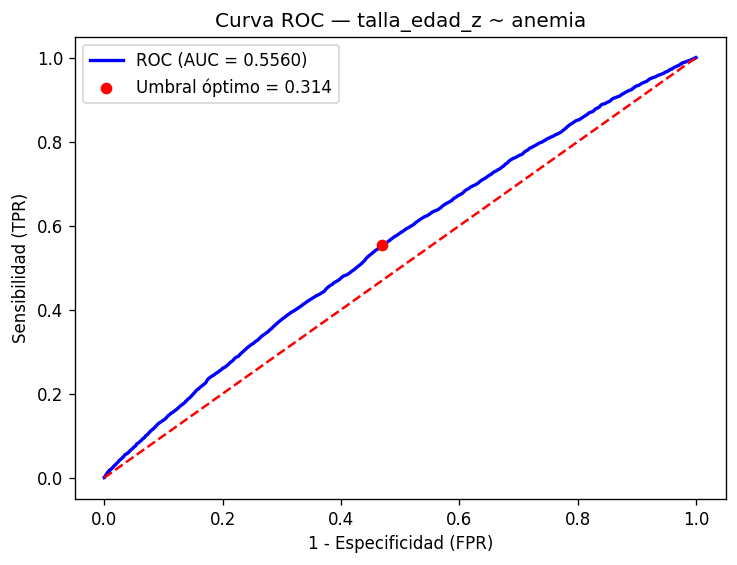

In [10]:
prob_full = modelo_sm.predict(X_sm)
auc_full  = roc_auc_score(y_sm, prob_full)
fpr, tpr, thresholds = roc_curve(y_sm, prob_full)

# Punto de corte óptimo (más cercano a esquina superior izquierda)
distancias  = np.sqrt(fpr**2 + (1 - tpr)**2)
idx_optimo  = np.argmin(distancias)
umbral_opt  = thresholds[idx_optimo]

print(f'AUC (modelo completo): {auc_full:.4f}')
print(f'Umbral óptimo       : {umbral_opt:.4f}')
print(f'  Sensibilidad       : {tpr[idx_optimo]:.4f}')
print(f'  Especificidad      : {1 - fpr[idx_optimo]:.4f}')

plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC (AUC = {auc_full:.4f})')
plt.plot([0,1],[0,1], 'r--')
plt.scatter(fpr[idx_optimo], tpr[idx_optimo], color='red', zorder=5,
            label=f'Umbral óptimo = {umbral_opt:.3f}')
plt.xlabel('1 - Especificidad (FPR)')
plt.ylabel('Sensibilidad (TPR)')
plt.title('Curva ROC — talla_edad_z ~ anemia')
plt.legend()
plt.savefig('2_curva_roc.png', dpi=120)
plt.show()

## 8 · Matriz de Confusión (modelo completo)

In [11]:
pred_full = (prob_full >= 0.5).astype(int)
cm = confusion_matrix(y_sm, pred_full)

print('Matriz de confusión (umbral = 0.5):')
print(pd.DataFrame(cm,
    index=['Obs: Sin anemia', 'Obs: Con anemia'],
    columns=['Pred: Sin anemia', 'Pred: Con anemia']))

acc  = accuracy_score(y_sm, pred_full)
err  = 1 - acc
print(f'\nAccuracy (entrenamiento): {acc:.4f} ({acc*100:.1f}%)')
print(f'Error de clasificación  : {err:.4f}')

# Exportar datos con predicciones
finaldata = datos.copy()
finaldata['prob']       = prob_full
finaldata['prediccion'] = pred_full
finaldata.to_csv('anemia_predict.csv', index=False)
print('\nGuardado: anemia_predict.csv')
finaldata.head(10)

Matriz de confusión (umbral = 0.5):
                 Pred: Sin anemia  Pred: Con anemia
Obs: Sin anemia             12547                 5
Obs: Con anemia              5750                 4

Accuracy (entrenamiento): 0.6856 (68.6%)
Error de clasificación  : 0.3144

Guardado: anemia_predict.csv


,anemia,talla_edad_z,prob,prediccion
0,0,-0.88,0.312820,0
1,0,-1.67,0.347470,0
2,0,-0.78,0.308570,0
3,1,-0.27,0.287403,0
4,0,-1.19,0.326196,0
5,0,-1.19,0.326196,0
6,0,-2.05,0.364761,0
7,0,-0.87,0.312394,0
8,1,-0.67,0.303932,0
9,1,-0.24,0.286185,0


## 9 · Predicción para nuevos valores

In [12]:
print(f'{"talla_edad_z":>14} | {"P(anemia)":>12} | Clasificación')
print('-' * 48)
for valor in [0, -1, -2, -3]:
    x_new  = np.array([[1, valor]])          # [const, talla_edad_z]
    p_pred = modelo_sm.predict(x_new)[0]
    clase  = 'Con anemia' if p_pred > 0.5 else 'Sin anemia'
    print(f'{valor:>14} | {p_pred:>12.4f} | {clase}')

  talla_edad_z |    P(anemia) | Clasificación
------------------------------------------------
             0 |       0.2766 | Sin anemia
            -1 |       0.3180 | Sin anemia
            -2 |       0.3625 | Sin anemia
            -3 |       0.4095 | Sin anemia


## 10 · Gráfico del modelo con intervalos de confianza

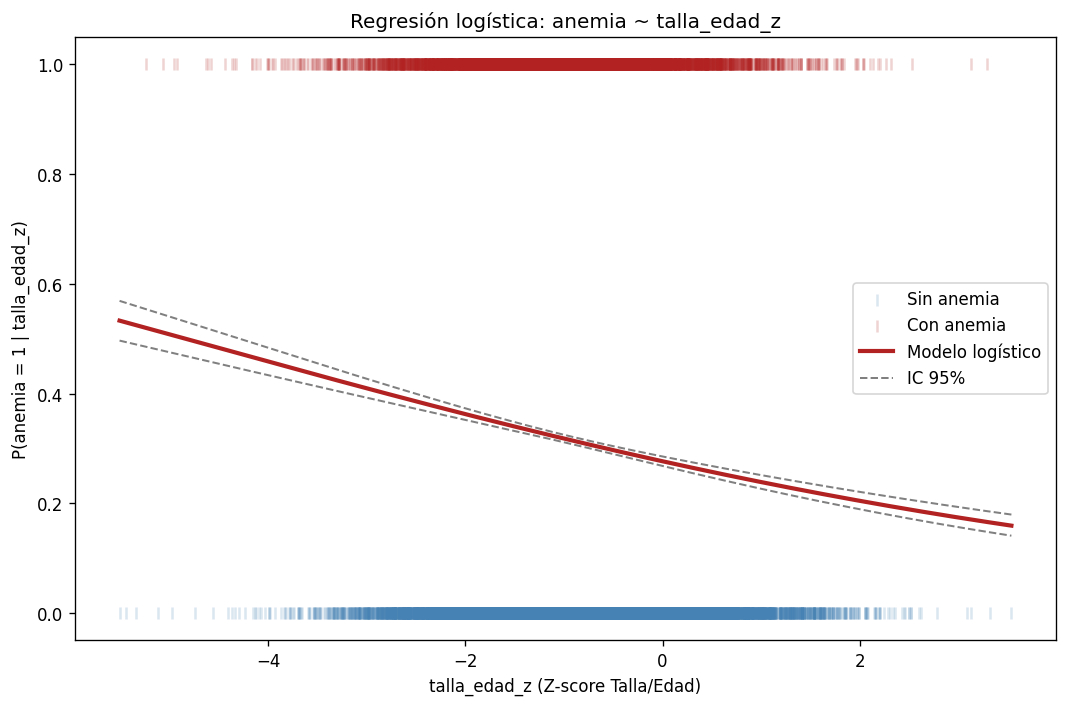

In [13]:
x_range = np.linspace(datos['talla_edad_z'].min(), datos['talla_edad_z'].max(), 300)
X_range = sm.add_constant(pd.DataFrame({'talla_edad_z': x_range}))

pred_logit = X_range @ modelo_sm.params
se_logit   = np.sqrt((X_range.values @ modelo_sm.cov_params().values * X_range.values).sum(axis=1))

p_media = 1 / (1 + np.exp(-pred_logit))
p_lwr   = 1 / (1 + np.exp(-(pred_logit - 1.96 * se_logit)))
p_upr   = 1 / (1 + np.exp(-(pred_logit + 1.96 * se_logit)))

plt.figure(figsize=(9, 6))
for grupo, color, etiq in [(0,'steelblue','Sin anemia'), (1,'firebrick','Con anemia')]:
    sub = datos[datos['anemia'] == grupo]
    plt.scatter(sub['talla_edad_z'], sub['anemia'], color=color,
                alpha=0.2, marker='|', s=50, label=etiq)

plt.plot(x_range, p_media, color='firebrick', lw=2.5, label='Modelo logístico')
plt.plot(x_range, p_lwr,   color='gray',      lw=1.2, linestyle='--', label='IC 95%')
plt.plot(x_range, p_upr,   color='gray',      lw=1.2, linestyle='--')

plt.xlabel('talla_edad_z (Z-score Talla/Edad)')
plt.ylabel('P(anemia = 1 | talla_edad_z)')
plt.title('Regresión logística: anemia ~ talla_edad_z')
plt.legend()
plt.tight_layout()
plt.savefig('3_modelo_con_ic.png', dpi=120)
plt.show()

## 11 · Regresión Logística como Machine Learning
### División Train / Test (70% / 30%)

In [14]:
X = datos[['talla_edad_z']].values
y = datos['anemia'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=123, stratify=y
)

print(f'Entrenamiento: {len(X_train)} observaciones')
print(f'Prueba       : {len(X_test)}  observaciones')

Entrenamiento: 12814 observaciones
Prueba       : 5492  observaciones


In [15]:
clf = LogisticRegression(random_state=123, max_iter=1000)
clf.fit(X_train, y_train)

print(f'Intercepto : {clf.intercept_[0]:.5f}')
print(f'Coeficiente: {clf.coef_[0][0]:.5f}')
print(f'OR (talla_edad_z): {np.exp(clf.coef_[0][0]):.5f}')

Intercepto : -0.95187
Coeficiente: -0.18908
OR (talla_edad_z): 0.82772


In [16]:
y_pred_train = clf.predict(X_train)
y_pred_test  = clf.predict(X_test)
y_prob_test  = clf.predict_proba(X_test)[:, 1]

acc_test  = accuracy_score(y_test, y_pred_test)
prec_test = precision_score(y_test, y_pred_test)
rec_test  = recall_score(y_test, y_pred_test)
f1_test   = f1_score(y_test, y_pred_test)
auc_test  = roc_auc_score(y_test, y_prob_test)

print('=== Métricas — Conjunto de Prueba ===')
print(f'Accuracy  : {acc_test:.4f} ({acc_test*100:.2f}%)')
print(f'Precisión : {prec_test:.4f}')
print(f'Recall    : {rec_test:.4f}')
print(f'F1-Score  : {f1_test:.4f}')
print(f'ROC-AUC   : {auc_test:.4f}')

print('\nReporte de clasificación (prueba):')
print(classification_report(y_test, y_pred_test,
                             target_names=['Sin anemia','Con anemia']))

=== Métricas — Conjunto de Prueba ===
Accuracy  : 0.6857 (68.57%)
Precisión : 0.0000
Recall    : 0.0000
F1-Score  : 0.0000
ROC-AUC   : 0.5602

Reporte de clasificación (prueba):
              precision    recall  f1-score   support

  Sin anemia       0.69      1.00      0.81      3766
  Con anemia       0.00      0.00      0.00      1726

    accuracy                           0.69      5492
   macro avg       0.34      0.50      0.41      5492
weighted avg       0.47      0.69      0.56      5492



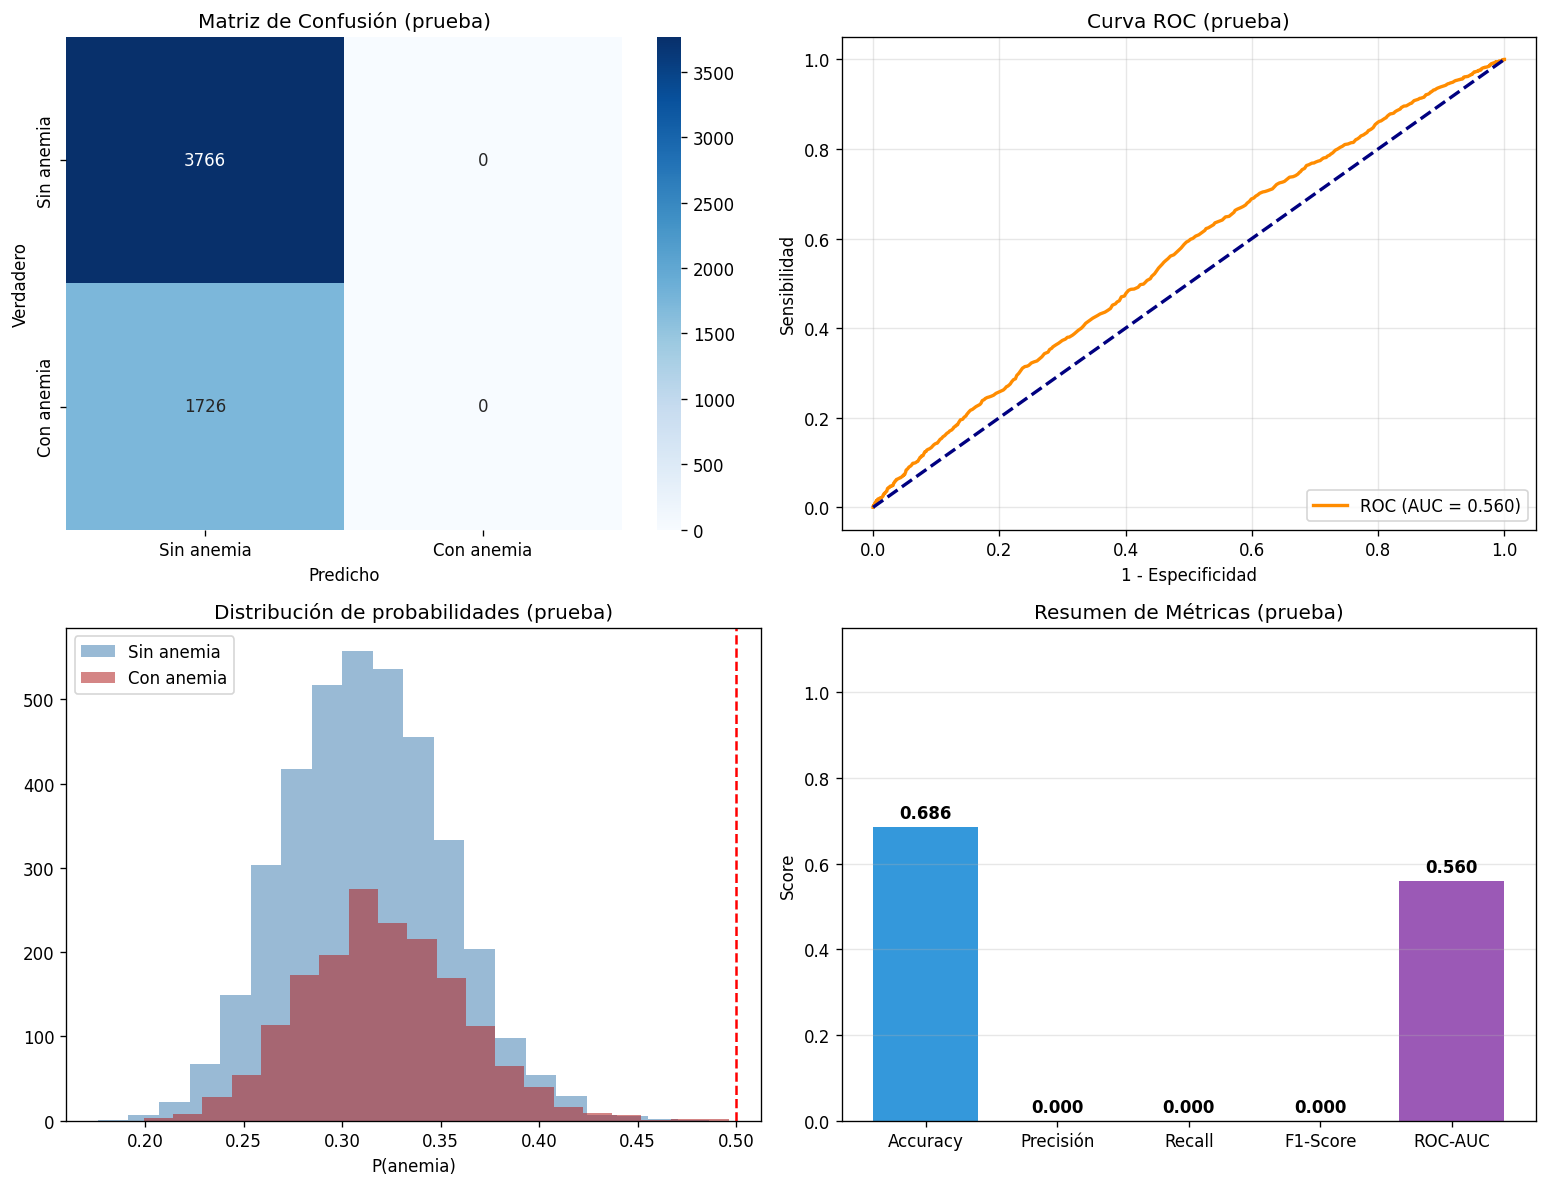

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# ── 1. Matriz de confusión ────────────────────────────────────────────────────
cm_test = confusion_matrix(y_test, y_pred_test)
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', ax=axes[0,0],
            xticklabels=['Sin anemia','Con anemia'],
            yticklabels=['Sin anemia','Con anemia'])
axes[0,0].set_xlabel('Predicho')
axes[0,0].set_ylabel('Verdadero')
axes[0,0].set_title('Matriz de Confusión (prueba)')

# ── 2. Curva ROC ──────────────────────────────────────────────────────────────
fpr_t, tpr_t, _ = roc_curve(y_test, y_prob_test)
axes[0,1].plot(fpr_t, tpr_t, color='darkorange', lw=2,
               label=f'ROC (AUC = {auc_test:.3f})')
axes[0,1].plot([0,1],[0,1],'navy',lw=2,linestyle='--')
axes[0,1].set_xlabel('1 - Especificidad')
axes[0,1].set_ylabel('Sensibilidad')
axes[0,1].set_title('Curva ROC (prueba)')
axes[0,1].legend(loc='lower right')
axes[0,1].grid(alpha=0.3)

# ── 3. Distribución de probabilidades ─────────────────────────────────────────
axes[1,0].hist(y_prob_test[y_test==0], bins=20,
               color='steelblue', alpha=0.55, label='Sin anemia')
axes[1,0].hist(y_prob_test[y_test==1], bins=20,
               color='firebrick', alpha=0.55, label='Con anemia')
axes[1,0].axvline(0.5, color='red', linestyle='--', linewidth=1.5)
axes[1,0].set_xlabel('P(anemia)')
axes[1,0].set_title('Distribución de probabilidades (prueba)')
axes[1,0].legend()

# ── 4. Métricas resumen ───────────────────────────────────────────────────────
nombres = ['Accuracy','Precisión','Recall','F1-Score','ROC-AUC']
valores = [acc_test, prec_test, rec_test, f1_test, auc_test]
colores_bar = ['#3498db','#e74c3c','#2ecc71','#f39c12','#9b59b6']
bars = axes[1,1].bar(nombres, valores, color=colores_bar)
for bar, val in zip(bars, valores):
    axes[1,1].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 0.02,
                   f'{val:.3f}', ha='center', fontweight='bold')
axes[1,1].set_ylim(0, 1.15)
axes[1,1].set_title('Resumen de Métricas (prueba)')
axes[1,1].set_ylabel('Score')
axes[1,1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('4_resultados_resumen.png', dpi=100)
plt.show()

## 12 · Validación Cruzada 10-Fold

=== Validación Cruzada 10-Fold ===
Accuracy : 0.6856
ROC-AUC  : 0.5558

Matriz de confusión (CV):
                 Pred: Sin anemia  Pred: Con anemia
Obs: Sin anemia             12547                 5
Obs: Con anemia              5750                 4


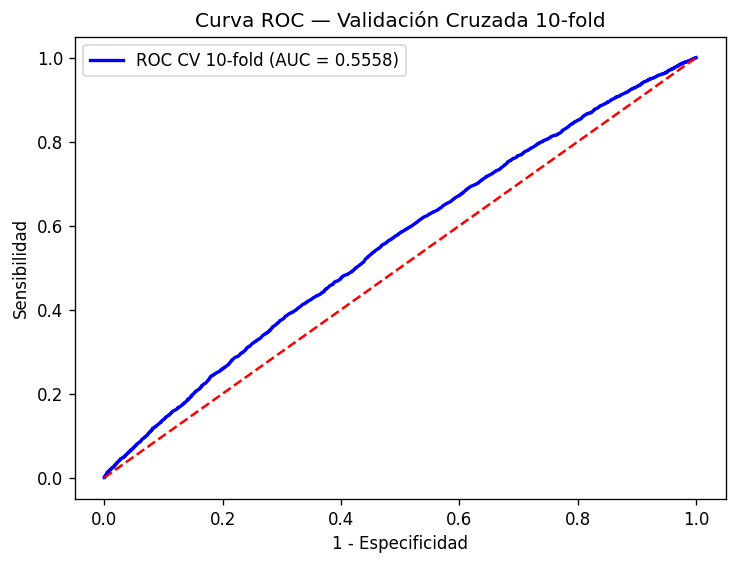

In [18]:
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=123)

y_pred_cv  = cross_val_predict(clf, X, y, cv=skf)
y_prob_cv  = cross_val_predict(clf, X, y, cv=skf, method='predict_proba')[:, 1]

acc_cv  = accuracy_score(y, y_pred_cv)
auc_cv  = roc_auc_score(y, y_prob_cv)

print('=== Validación Cruzada 10-Fold ===')
print(f'Accuracy : {acc_cv:.4f}')
print(f'ROC-AUC  : {auc_cv:.4f}')

print('\nMatriz de confusión (CV):')
cm_cv = confusion_matrix(y, y_pred_cv)
print(pd.DataFrame(cm_cv,
    index=['Obs: Sin anemia','Obs: Con anemia'],
    columns=['Pred: Sin anemia','Pred: Con anemia']))

# Curva ROC — CV
fpr_cv, tpr_cv, _ = roc_curve(y, y_prob_cv)
plt.figure()
plt.plot(fpr_cv, tpr_cv, color='blue', lw=2,
         label=f'ROC CV 10-fold (AUC = {auc_cv:.4f})')
plt.plot([0,1],[0,1],'r--')
plt.xlabel('1 - Especificidad')
plt.ylabel('Sensibilidad')
plt.title('Curva ROC — Validación Cruzada 10-fold')
plt.legend()
plt.savefig('5_roc_cv.png', dpi=120)
plt.show()

## 13 · Resumen Ejecutivo

In [19]:
or_tez = np.exp(modelo_sm.params['talla_edad_z'])

print('═' * 65)
print('MODELO: Regresión Logística Simple')
print('  Variable dependiente  : presencia de anemia (0=Sin, 1=Con)')
print('  Variable independiente: talla_edad_z (Z-score Talla/Edad, OMS)')
print(f'  logit(anemia) = {b0:.4f} + ({b1:.4f}) × talla_edad_z')
print(f'  Odds Ratio (talla_edad_z)     : {or_tez:.4f}')
print(f'  AIC                           : {modelo_sm.aic:.2f}')
print(f'  Pseudo R² McFadden            : {mcf:.4f}')
print(f'  AUC-ROC (modelo completo)     : {auc_full:.4f}')
print(f'  AUC-ROC (prueba 30%)          : {auc_test:.4f}')
print(f'  AUC-ROC (CV 10-fold)          : {auc_cv:.4f}')
print(f'  Por cada unidad que AUMENTA talla_edad_z, las odds de tener')
print(f'  anemia se REDUCEN un {(1-or_tez)*100:.1f}%.')
print('  El predictor es estadísticamente significativo (p < 0.001).')
print('═' * 65)
print('Análisis completado ✓')

═════════════════════════════════════════════════════════════════
MODELO: Regresión Logística Simple
  Variable dependiente  : presencia de anemia (0=Sin, 1=Con)
  Variable independiente: talla_edad_z (Z-score Talla/Edad, OMS)
  logit(anemia) = -0.9616 + (-0.1985) × talla_edad_z
  Odds Ratio (talla_edad_z)     : 0.8200
  AIC                           : 22638.39
  Pseudo R² McFadden            : 0.0069
  AUC-ROC (modelo completo)     : 0.5560
  AUC-ROC (prueba 30%)          : 0.5602
  AUC-ROC (CV 10-fold)          : 0.5558
  Por cada unidad que AUMENTA talla_edad_z, las odds de tener
  anemia se REDUCEN un 18.0%.
  El predictor es estadísticamente significativo (p < 0.001).
═════════════════════════════════════════════════════════════════
Análisis completado ✓
